In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

random_s = 101

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster_mpg.csv')
df.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [ ]:
df = df.drop('name',axis=1)
display(df.head())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


In [ ]:
df = pd.get_dummies(df, columns=['origin'], drop_first=False).astype(float)
display(df.head())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,0.0,0.0,1.0
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,0.0,0.0,1.0
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,0.0,0.0,1.0
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,0.0,0.0,1.0
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,0.0,0.0,1.0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled_1 = scaler.fit_transform(df)
display(df_scaled_1)

array([[-0.69863841,  1.48394702,  1.07728956, ..., -0.45812285,
        -0.50239045,  0.77459667],
       [-1.08349824,  1.48394702,  1.48873169, ..., -0.45812285,
        -0.50239045,  0.77459667],
       [-0.69863841,  1.48394702,  1.1825422 , ..., -0.45812285,
        -0.50239045,  0.77459667],
       ...,
       [ 1.09737414, -0.86401356, -0.56847897, ..., -0.45812285,
        -0.50239045,  0.77459667],
       [ 0.5842277 , -0.86401356, -0.7120053 , ..., -0.45812285,
        -0.50239045,  0.77459667],
       [ 0.96908753, -0.86401356, -0.72157372, ..., -0.45812285,
        -0.50239045,  0.77459667]])

In [ ]:
displacement_index = df.columns.get_loc('displacement')
scaled_displacement_85 = df_scaled_1[85, displacement_index]
print(f"The scaled value of displacement at index 85 is: {scaled_displacement_85}")

The scaled value of displacement at index 85 is: 1.048584292818992


In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca_5 = PCA(n_components=5)
pca_5.fit(df_scaled_1)
loadings = pd.DataFrame(abs(pca_5.components_.T), columns = ['PC{}'.format(i) for i in np.arange(5)], index = df.columns)
display(loadings.sort_values(by = 'PC0', ascending = False))

,PC0,PC1,PC2,PC3,PC4
displacement,0.401424,0.040104,0.014242,0.105105,0.177852
cylinders,0.386894,0.043270,0.020064,0.108264,0.251762
weight,0.385033,0.007805,0.040943,0.113506,0.397484
horsepower,0.379861,0.014239,0.232914,0.205505,0.056248
mpg,0.368204,0.152581,0.047510,0.256083,0.150529
origin_usa,0.302482,0.234523,0.503875,0.174551,0.353844
acceleration,0.247214,0.041983,0.447133,0.437151,0.663007
origin_japan,0.213090,0.425699,0.603595,0.119644,0.302273
model_year,0.192661,0.413815,0.350777,0.705839,0.218046
origin_europe,0.160989,0.750832,0.004778,0.349922,0.132178


In [ ]:
print(f"The explained variance of PC0 is: {pca_5.explained_variance_ratio_[0]}")
print(f"The total explained variance of PC0 and PC1 is: {pca_5.explained_variance_ratio_[0] + pca_5.explained_variance_ratio_[1]}")

The explained variance of PC0 is: 0.5788575314058662
The total explained variance of PC0 and PC1 is: 0.7118300241528728


In [ ]:
correlation_matrix = df.corr()

# Display the correlation matrix

correlation_matrix

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.244313,0.451454,-0.565161
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.352324,-0.404209,0.610494
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.371633,-0.440825,0.655936
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.284948,-0.321936,0.489625
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.293841,-0.447929,0.600978
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.208298,0.115020,-0.258224
model_year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,-0.037745,0.199841,-0.136065
origin_europe,0.244313,-0.352324,-0.371633,-0.284948,-0.293841,0.208298,-0.037745,1.000000,-0.230157,-0.591434
origin_japan,0.451454,-0.404209,-0.440825,-0.321936,-0.447929,0.115020,0.199841,-0.230157,1.000000,-0.648583
origin_usa,-0.565161,0.610494,0.655936,0.489625,0.600978,-0.258224,-0.136065,-0.591434,-0.648583,1.000000


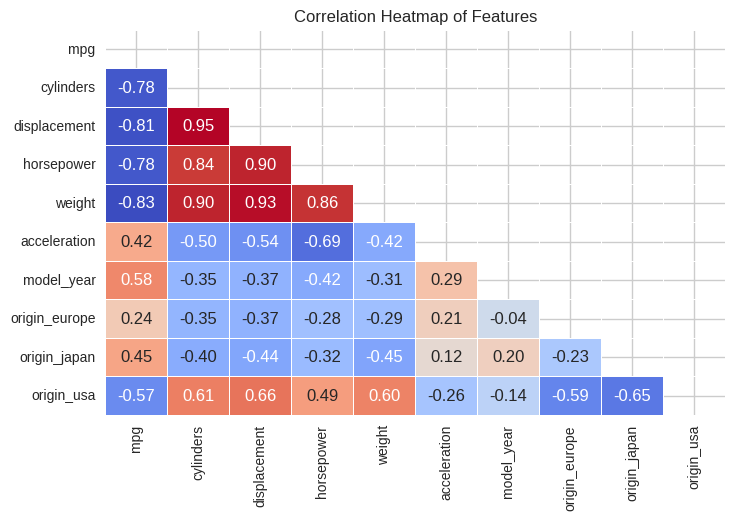

In [ ]:
plt.figure(figsize = (8,5))
mask = np.triu(np.ones_like(correlation_matrix, dtype = bool))

sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm',
            linewidths = 0.5, fmt = '.2f', annot_kws={"size": 12}, cbar = False, mask = mask)
plt.title("Correlation Heatmap of Features")
plt.show()

In [ ]:
correlation_matrix[correlation_matrix < 1].unstack().drop_duplicates().sort_values(ascending = False)

,,0
cylinders,displacement,0.950823
displacement,weight,0.932994
cylinders,weight,0.897527
displacement,horsepower,0.897257
horsepower,weight,0.864538
cylinders,horsepower,0.842983
displacement,origin_usa,0.655936
cylinders,origin_usa,0.610494
weight,origin_usa,0.600978
mpg,model_year,0.580541


In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(df_scaled_1)
explained_variance = pca.explained_variance_ratio_
components = pca.components_

explained_variance, components

(array([0.57885753, 0.13297249, 0.11850505, 0.07328586, 0.05852549,
        0.01825335, 0.0112476 , 0.00530801, 0.00304462, 0.        ]),
 array([[-3.68203717e-01,  3.86894349e-01,  4.01424093e-01,
          3.79861114e-01,  3.85032556e-01, -2.47214254e-01,
         -1.92660853e-01, -1.60988643e-01, -2.13089870e-01,
          3.02481767e-01],
        [-1.52580773e-01, -4.32702688e-02, -4.01040260e-02,
          1.42386673e-02,  7.80536760e-03,  4.19827885e-02,
         -4.13815489e-01,  7.50831804e-01, -4.25698631e-01,
         -2.34523473e-01],
        [-4.75104736e-02,  2.00635457e-02,  1.42422130e-02,
          2.32913680e-01, -4.09429126e-02, -4.47132733e-01,
         -3.50776950e-01,  4.77795581e-03,  6.03595273e-01,
         -5.03875016e-01],
        [ 2.56082989e-01,  1.08264258e-01,  1.05105017e-01,
          2.05505495e-01,  1.13505686e-01, -4.37150629e-01,
          7.05838941e-01,  3.49921568e-01, -1.19643989e-01,
         -1.74551333e-01],
        [-1.50529154e-01,  2.51761

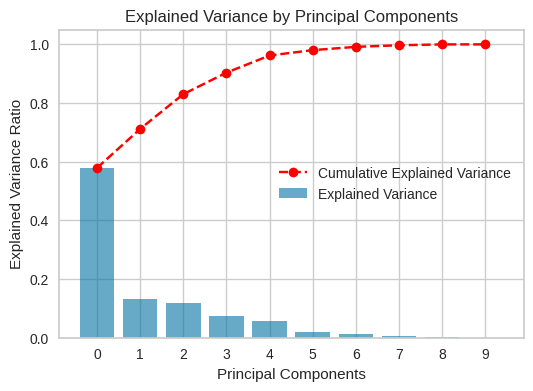

In [ ]:
plt.figure(figsize=(6, 4))

plt.plot(np.cumsum(explained_variance), marker='o', linestyle='--', label = 'Cumulative Explained Variance', color = 'red')

plt.bar(range(0, len(explained_variance)), explained_variance, alpha = 0.6, label='Explained Variance')

plt.title('Explained Variance by Principal Components')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(0, len(explained_variance)))
plt.grid(True)
plt.legend(loc = 'center right')
plt.show()


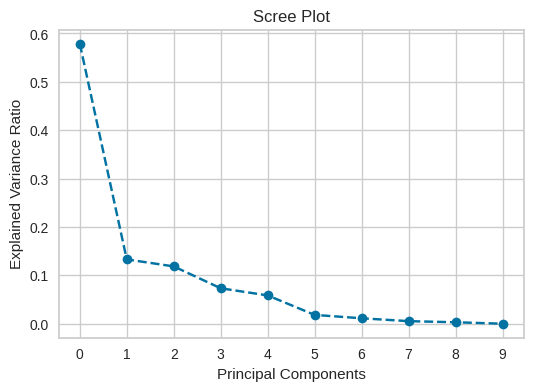

In [ ]:
plt.figure(figsize=(6, 4))

plt.plot(range(0, len(explained_variance)), explained_variance, marker='o', linestyle='--', label='Explained Variance')

plt.title('Scree Plot')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(0, len(explained_variance)))
plt.grid(True)

plt.show()

In [ ]:
df_loadings = pd.DataFrame(pca.components_, columns=df.columns, index=[f'PC{i}' for i in range(len(pca.components_))])
display(df_loadings)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
PC0,-3.682037e-01,3.868943e-01,4.014241e-01,3.798611e-01,3.850326e-01,-2.472143e-01,-1.926609e-01,-0.160989,-0.213090,0.302482
PC1,-1.525808e-01,-4.327027e-02,-4.010403e-02,1.423867e-02,7.805368e-03,4.198279e-02,-4.138155e-01,0.750832,-0.425699,-0.234523
PC2,-4.751047e-02,2.006355e-02,1.424221e-02,2.329137e-01,-4.094291e-02,-4.471327e-01,-3.507769e-01,0.004778,0.603595,-0.503875
PC3,2.560830e-01,1.082643e-01,1.051050e-01,2.055055e-01,1.135057e-01,-4.371506e-01,7.058389e-01,0.349922,-0.119644,-0.174551
PC4,-1.505292e-01,2.517617e-01,1.778519e-01,5.624825e-02,3.974843e-01,6.630074e-01,2.180460e-01,0.132178,0.302273,-0.353844
PC5,7.500744e-01,4.777093e-01,3.005651e-01,-6.692718e-02,-1.169983e-01,1.015640e-01,-2.981610e-01,0.014992,-0.031913,0.014717
PC6,3.659196e-01,-5.459201e-01,-2.234672e-03,6.746037e-01,2.125183e-01,2.128594e-01,-1.127079e-01,-0.048129,-0.044280,0.074334
PC7,1.952151e-01,-3.106599e-01,1.167903e-01,-5.299297e-01,7.098083e-01,-2.224340e-01,-1.284863e-01,-0.015476,0.027401,-0.010600
PC8,-1.266203e-01,-3.875414e-01,8.308940e-01,-1.243491e-01,-3.412551e-01,3.760579e-02,6.877249e-02,0.038002,0.030063,-0.054632
PC9,2.096495e-15,1.934980e-15,-7.628463e-15,5.165376e-15,1.002336e-15,8.245468e-16,-5.569932e-16,0.515917,0.546561,0.659621


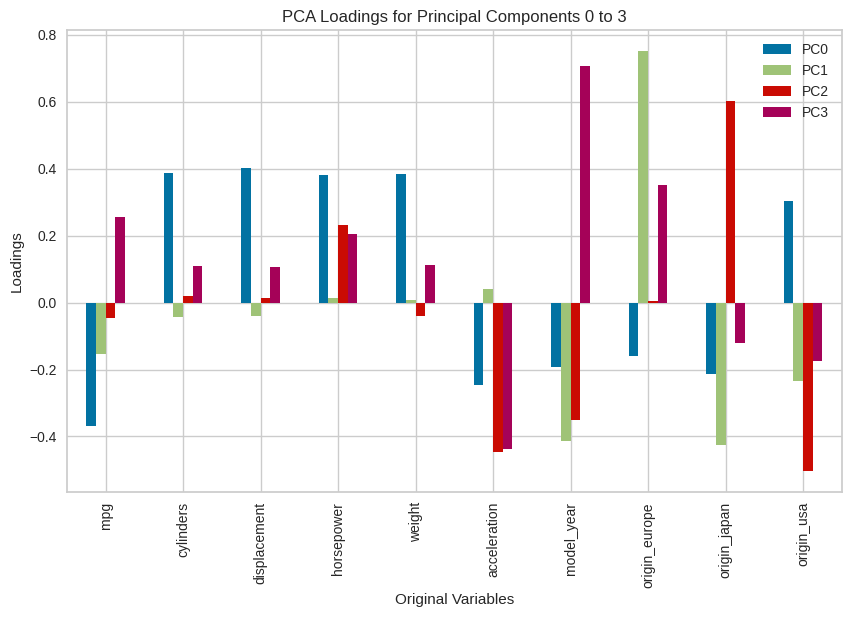

In [ ]:
loadings_df = pd.DataFrame(pca.components_[:4].T, columns=[f'PC{i}' for i in range(4)], index=df.columns)

# Plotting the loadings for PC0 to PC3

plt.figure(figsize=(10, 6))

# Create a bar plot for the loadings of each principal component

loadings_df.plot(kind='bar', ax=plt.gca())

plt.title('PCA Loadings for Principal Components 0 to 3')
plt.xlabel('Original Variables')
plt.ylabel('Loadings')
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# 5. What is the total explained variance of PC0, PC1 and PC2?
total_explained_variance_pc0_pc1_pc2 = pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1] + pca.explained_variance_ratio_[2]
print(f"The total explained variance of PC0, PC1, and PC2 is: {total_explained_variance_pc0_pc1_pc2}")

# 6. Using only two principal components, what is the value of PC0 and PC1 at index 285?
pca_2 = PCA(n_components=2)
df_pca_2 = pca_2.fit_transform(df_scaled_1)
print(f"Using two components, the values of PC0 and PC1 at index 285 are: {df_pca_2[285, 0]}, {df_pca_2[285, 1]}")

# 7. Using three principal components, what is the value of PC0, PC1, and PC2 at index 300?
pca_3 = PCA(n_components=3)
df_pca_3 = pca_3.fit_transform(df_scaled_1)
print(f"Using three components, the values of PC0, PC1, and PC2 at index 300 are: {df_pca_3[300, 0]}, {df_pca_3[300, 1]}, {df_pca_3[300, 2]}")

The total explained variance of PC0, PC1, and PC2 is: 0.8303350791192141
Using two components, the values of PC0 and PC1 at index 285 are: 2.7456413189807485, -0.6541014878447338
Using three components, the values of PC0, PC1, and PC2 at index 300 are: -1.6016079686808165, -0.8263315855241968, -1.1454320362883155


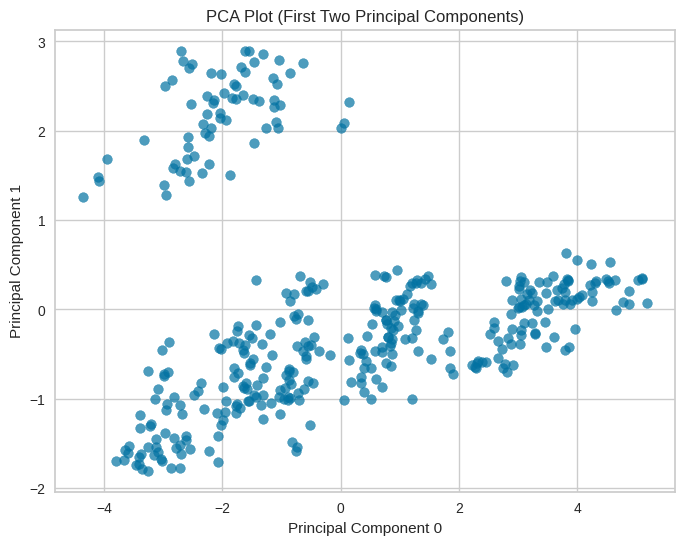

In [ ]:
# Project the original data onto the first two principal components

pca_2d = PCA(n_components = 2)
data_pca_2d = pca_2d.fit_transform(df_scaled_1)

# Create a scatter plot of the first two principal components

plt.figure(figsize=(8, 6))

plt.scatter(data_pca_2d[:, 0], data_pca_2d[:, 1], alpha = 0.7)

plt.title('PCA Plot (First Two Principal Components)')
plt.xlabel('Principal Component 0')
plt.ylabel('Principal Component 1')
plt.grid(True)
plt.show()

In [ ]:
# Project the original data onto the first three principal components

pca_3d = PCA(n_components = 3)
data_pca_3d = pca_3d.fit_transform(df_scaled_1)

# 3D Plot

import plotly.express as px

fig = px.scatter_3d(df_scaled_1, x = data_pca_3d[:,0], y = data_pca_3d[:,1], z = data_pca_3d[:,2], opacity = 0.8,
                    color_discrete_sequence =['red'], title = 'Scatter Plot of Principal Components (PC0, PC1 & PC2)')

fig.add_scatter3d(
    x=[df_pca_3[200, 0]],
    y=[df_pca_3[200, 1]],
    z=[df_pca_3[200, 2]],
    mode='markers',
    marker=dict(
        color='black',
        size=10,
        symbol='circle'
    ),
    name='Data Point at Index 200'
)

fig.show()

In [ ]:
data_pca_2d

array([[ 2.80100539e+00,  3.20338831e-01],
       [ 3.58436772e+00,  3.69644872e-01],
       [ 3.09974246e+00,  3.07663108e-01],
       [ 3.04935633e+00,  3.67392762e-01],
       [ 3.03746943e+00,  3.22174143e-01],
       [ 4.64258774e+00,  3.34659943e-01],
       [ 5.09886121e+00,  3.37672106e-01],
       [ 5.02147832e+00,  3.33187517e-01],
       [ 5.09461273e+00,  3.55030475e-01],
       [ 4.32546660e+00,  3.19289372e-01],
       [ 3.83610616e+00,  3.34782248e-01],
       [ 3.81968689e+00,  3.37102387e-01],
       [ 3.83850368e+00,  3.15054299e-01],
       [ 4.48687091e+00,  3.42710352e-01],
       [-1.42078737e+00, -1.75516842e-01],
       [ 7.74761226e-01,  3.68859210e-01],
       [ 9.60528684e-01,  4.46969687e-01],
       [ 5.74350097e-01,  3.89316874e-01],
       [-1.75809735e+00, -2.40537161e-01],
       [-2.69206070e+00,  2.89630476e+00],
       [-1.54069406e+00,  2.88806706e+00],
       [-1.31601024e+00,  2.86196627e+00],
       [-1.61949041e+00,  2.89059990e+00],
       [-1.

In [ ]:
data_pca_3d

array([[ 2.80100539,  0.32033883,  0.65666252],
       [ 3.58436772,  0.36964487,  0.96488362],
       [ 3.09974246,  0.30766311,  0.94489847],
       ...,
       [-1.0251571 , -1.17010846, -0.79879666],
       [-1.42150948, -0.97821378, -1.95863113],
       [-1.56607216, -1.0223775 , -2.09328358]])

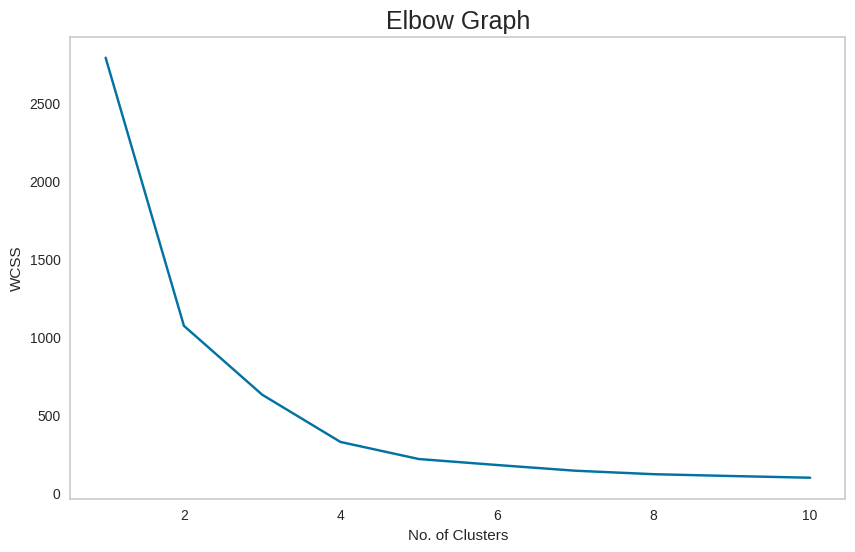

Silhouette Score for K=4: 0.443


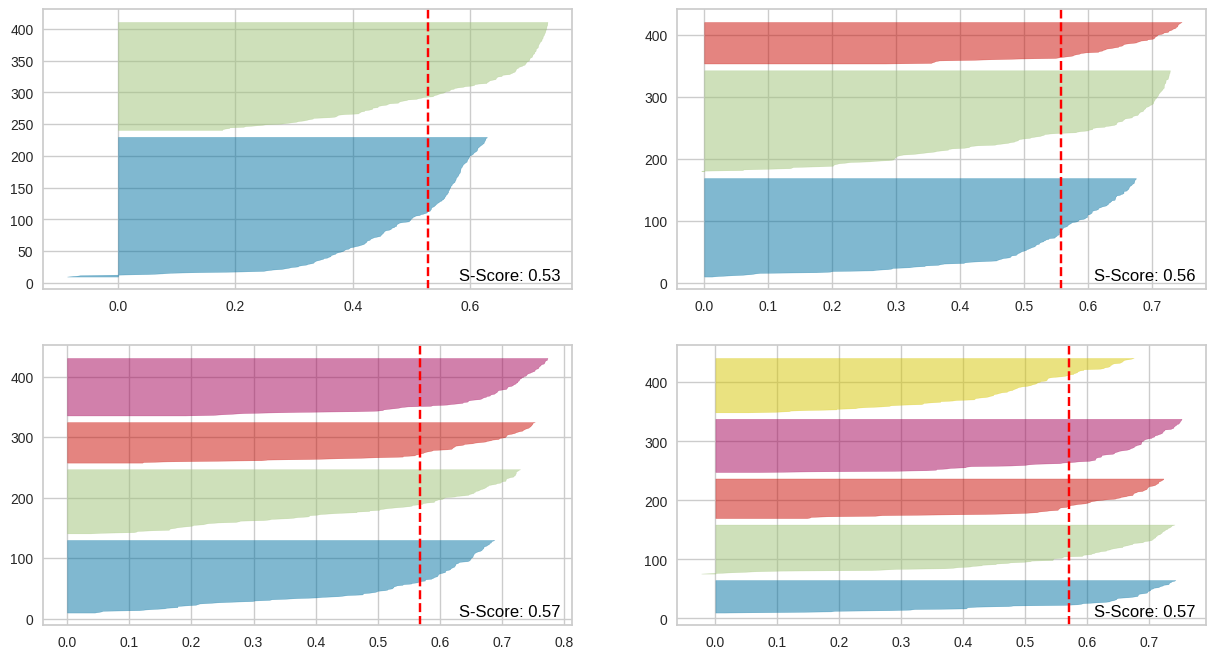

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

pca_2_components = PCA(n_components=2)
df_pca_2 = pca_2_components.fit_transform(df_scaled_1)

wcss = []
for i in range(1, 11):
    model = KMeans(n_clusters = i, random_state = random_s, n_init=10)
    model.fit(df_pca_2)
    wcss.append(model.inertia_)

plt.figure(figsize = (10,6))
plt.plot(range(1, 11), wcss)
plt.title('Elbow Graph', fontsize = 18)
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

score = silhouette_score(df_pca_2, model.labels_, metric = 'euclidean')
print('Silhouette Score for K=4: %.3f' %score)

fig, ax = plt.subplots(2,2, figsize = (15,8))

for i in [2, 3, 4, 5]:

  # Create KMeans instance for different number of clusters

  km = KMeans(n_clusters = i, random_state = 101, n_init = 'auto')
  q, mod = divmod(i, 2)

  # Create SilhouetteVisualizer

  visualizer = SilhouetteVisualizer(km, colors = 'yellowbrick', ax = ax[q - 1][mod])
  visualizer.fit(data_pca_2d)

  # Annotate the silhouette score on the plot
  silhouette_score = visualizer.silhouette_score_
  ax[q - 1][mod].text(0.98, 0.02, f'S-Score: {silhouette_score:.2f}',
                      transform = ax[q - 1][mod].transAxes,
                      ha='right', va='bottom', fontsize=12, color='black')

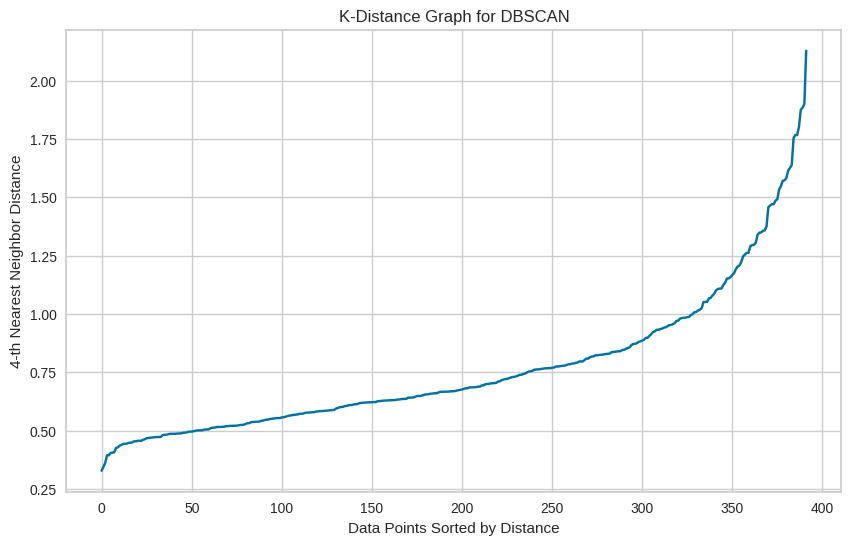

In [ ]:
from sklearn.neighbors import NearestNeighbors
min_samples = 4

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(df_scaled_1)

distances, indices = neighbors_fit.kneighbors(df_scaled_1)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title('K-Distance Graph for DBSCAN')
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

The optimal epsilon based on the highest Silhouette Score is: 1.29
The corresponding Silhouette Score is: 0.366


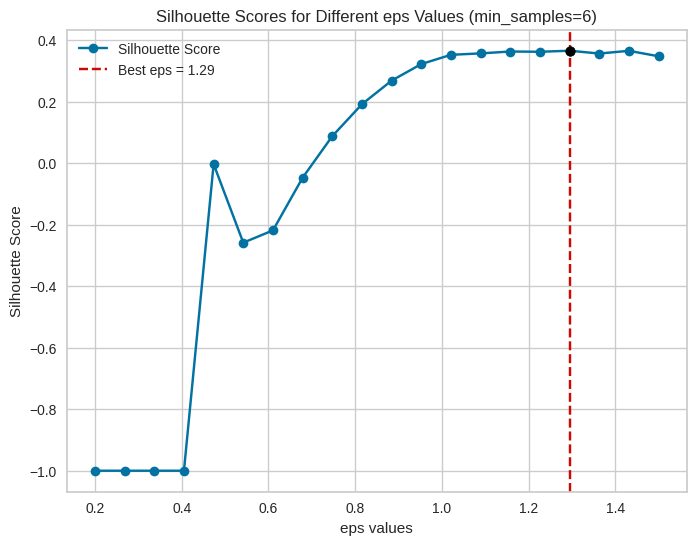

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

# Define min_samples as requested by the user
min_samples = 6

# Define range of potential eps values
# Based on the k-distance plot in cell o952VL1SLHSv, the elbow was around 0.6.
# The user suggested optimal epsilon 1.23, which is outside the current range.
# Let's expand the range to include 1.23 for evaluation.
eps_values = np.linspace(0.2, 1.5, 20) # Expanded range to include 1.23

# Store S-Scores
s_scores = []

# Evaluate DBScan for each eps_values and calculate S-Score
for eps in eps_values:

    dbscan = DBSCAN(eps = eps, min_samples = min_samples)  # DBSCAN
    labels = dbscan.fit_predict(df_scaled_1) # Use df_scaled

    # Check if the clustering has more than 1 cluster and not all points are noise (-1)
    # silhouette_score requires at least two clusters and more than one sample in total
    if len(set(labels)) > 1 and len(set(labels)) < len(labels):

        score = silhouette_score(df_scaled_1, labels)

    else:
        # Assign a low score or handle as invalid if clustering is trivial (all noise or single cluster)
        score = -1

    s_scores.append(score)

# Plot the S-Scores
# Plot the Silhouette Scores for different eps values

plt.figure(figsize=(8, 6))

# Plot silhouette scores for each eps value
plt.plot(eps_values, s_scores, marker='o', label='Silhouette Score')

# Add labels and title
plt.title('Silhouette Scores for Different eps Values (min_samples=6)')
plt.xlabel('eps values')
plt.ylabel('Silhouette Score')
plt.grid(True)

# Highlight the best eps
# Find the index of the best s_score, excluding -1 scores if any
valid_scores = [s for s in s_scores if s > -1]
if valid_scores:
    best_s_score = max(valid_scores)
    best_eps_index = s_scores.index(best_s_score)
    best_eps = eps_values[best_eps_index]

    plt.axvline(x = best_eps, color='r', linestyle='--', label = f'Best eps = {best_eps:.2f}')
    plt.scatter(best_eps, best_s_score, color='black', zorder = 5)
    plt.legend()
    print(f"The optimal epsilon based on the highest Silhouette Score is: {best_eps:.2f}")
    print(f"The corresponding Silhouette Score is: {best_s_score:.3f}")
else:
    print("Could not find a valid clustering with more than one cluster and not all noise for the tested epsilon range.")


plt.show()

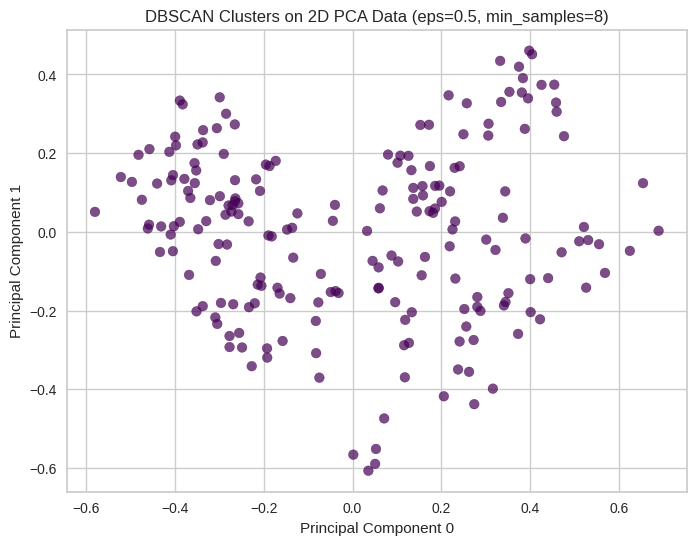

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

# Visualize the DBSCAN clusters on the 2D PCA data
plt.figure(figsize=(8, 6))

# Use data_pca_2d from cell E5iP1N6ZHKr9
# Perform DBSCAN on the 2D PCA data
dbscan_2d = DBSCAN(eps=0.5, min_samples=8)
labels_2d = dbscan_2d.fit_predict(data_pca_2d)

plt.scatter(data_pca_2d[:, 0], data_pca_2d[:, 1], c=labels_2d, cmap='viridis', alpha=0.7)

plt.title('DBSCAN Clusters on 2D PCA Data (eps=0.5, min_samples=8)')
plt.xlabel('Principal Component 0')
plt.ylabel('Principal Component 1')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
# Use the optimal_epsilon calculated from the Silhouette Scores in cell eIrE7Xh4VhIo
optimal_epsilon = 1.36
recommended_min_samples = 8

dbscan = DBSCAN(eps=optimal_epsilon, min_samples=recommended_min_samples)
clusters = dbscan.fit_predict(df_scaled_1)

num_outliers = np.sum(clusters == -1)

print(f"Based on the optimal epsilon ({optimal_epsilon}) and recommended min_samples ({recommended_min_samples}), DBSCAN detected {num_outliers} outliers.")

Based on the optimal epsilon (1.36) and recommended min_samples (8), DBSCAN detected 28 outliers.


## **A.Visualize the x = PC0 and y = PC1, Show Data 200 with marker of star (*) using 2D scatter plot**

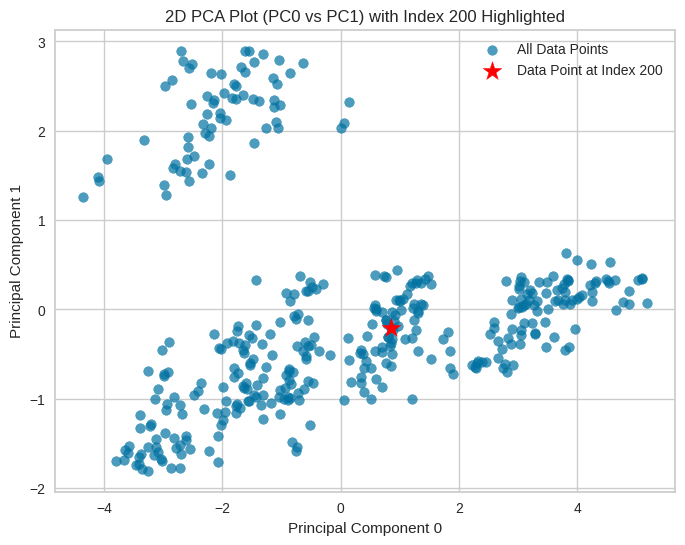

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(df_pca_2[:, 0], df_pca_2[:, 1], alpha=0.7, label='All Data Points')

plt.scatter(df_pca_2[200, 0], df_pca_2[200, 1], color='red', marker='*', s=200, label='Data Point at Index 200')

plt.title('2D PCA Plot (PC0 vs PC1) with Index 200 Highlighted')
plt.xlabel('Principal Component 0')
plt.ylabel('Principal Component 1')
plt.grid(True)
plt.legend()
plt.show()

## **B. Visualize the x = PC0, y = PC1, and z = PC2, Show or Trace Data 200 with black circle, using scatter_3D.**

In [ ]:
pca_3d = PCA(n_components = 3)
data_pca_3d = pca_3d.fit_transform(df_scaled_1)

import plotly.express as px

fig = px.scatter_3d(df_scaled_1, x = data_pca_3d[:,0], y = data_pca_3d[:,1], z = data_pca_3d[:,2], opacity = 0.8,
                    color_discrete_sequence =['red'], title = 'Scatter Plot of Principal Components (PC0, PC1 & PC2)')

fig.add_scatter3d(
    x=[df_pca_3[200, 0]],
    y=[df_pca_3[200, 1]],
    z=[df_pca_3[200, 2]],
    mode='markers',
    marker=dict(
        color='black',
        size=10,
        symbol='circle'
    ),
    name='Data Point at Index 200'
)

fig.show()

In [ ]:
pca_3d = PCA(n_components = 3)
data_pca_3d = pca_3d.fit_transform(df_scaled_1)

data_pca_3d_df = pd.DataFrame(data_pca_3d, columns = ['PC0', 'PC1', 'PC2'])
data_pca_3d_df

,PC0,PC1,PC2
0,2.801005,0.320339,0.656663
1,3.584368,0.369645,0.964884
2,3.099742,0.307663,0.944898
3,3.049356,0.367393,0.793047
4,3.037469,0.322174,0.968737
...,...,...,...
387,-0.884229,-1.007914,-1.428527
388,-4.345385,1.261627,-2.119235
389,-1.025157,-1.170108,-0.798797
390,-1.421509,-0.978214,-1.958631


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

random_s = 101

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/master/Data%20Sets/Mall_Customers.csv')
df.head(5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df = df.drop(['CustomerID', 'Gender'], axis=1)

display(df.head())

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [ ]:
df = pd.get_dummies(df).astype('float')
df.head(5)

,Age,Annual Income (k$),Spending Score (1-100)
0,19.0,15.0,39.0
1,21.0,15.0,81.0
2,20.0,16.0,6.0
3,23.0,16.0,77.0
4,31.0,17.0,40.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled_2 = scaler.fit_transform(df)
df_scaled_2

array([[0.01923077, 0.        , 0.3877551 ],
       [0.05769231, 0.        , 0.81632653],
       [0.03846154, 0.00819672, 0.05102041],
       [0.09615385, 0.00819672, 0.7755102 ],
       [0.25      , 0.01639344, 0.39795918],
       [0.07692308, 0.01639344, 0.76530612],
       [0.32692308, 0.02459016, 0.05102041],
       [0.09615385, 0.02459016, 0.94897959],
       [0.88461538, 0.03278689, 0.02040816],
       [0.23076923, 0.03278689, 0.7244898 ],
       [0.94230769, 0.03278689, 0.13265306],
       [0.32692308, 0.03278689, 1.        ],
       [0.76923077, 0.04098361, 0.14285714],
       [0.11538462, 0.04098361, 0.7755102 ],
       [0.36538462, 0.04098361, 0.12244898],
       [0.07692308, 0.04098361, 0.79591837],
       [0.32692308, 0.04918033, 0.34693878],
       [0.03846154, 0.04918033, 0.66326531],
       [0.65384615, 0.06557377, 0.28571429],
       [0.32692308, 0.06557377, 0.98979592],
       [0.32692308, 0.07377049, 0.34693878],
       [0.13461538, 0.07377049, 0.73469388],
       [0.

In [ ]:
df_reduced_s2 = pd.DataFrame(df_scaled_2, columns = df.columns)
df_reduced_s2.head(5)

,Age,Annual Income (k$),Spending Score (1-100)
0,0.019231,0.000000,0.387755
1,0.057692,0.000000,0.816327
2,0.038462,0.008197,0.051020
3,0.096154,0.008197,0.775510
4,0.250000,0.016393,0.397959


In [ ]:
from sklearn.decomposition import PCA

# Apply PCA

pca = PCA()
pca.fit(df_reduced_s2)

# Extract the explained variance ration and components

explained_variance = pca.explained_variance_ratio_
components = pca.components_ # should you need to see the feature loadings value

# Display the explained variance and components

explained_variance, components

(array([0.5002501 , 0.25327226, 0.24647764]),
 array([[ 0.72749676, -0.01902368, -0.68584733],
        [ 0.68360852, -0.06520257,  0.72693055],
        [ 0.0585479 ,  0.9976907 ,  0.03442991]]))

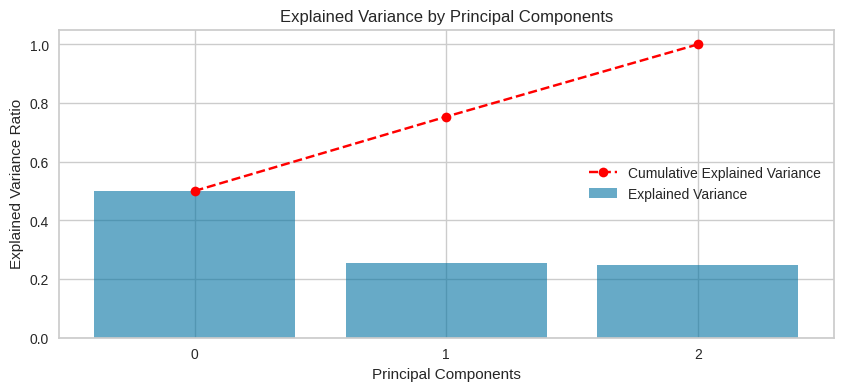

In [ ]:
plt.figure(figsize=(10, 4))

# Plot the cumulative explained variance

plt.plot(np.cumsum(explained_variance), marker='o', linestyle='--', label = 'Cumulative Explained Variance', color = 'red')

# Plot the individual explained variance for each component

plt.bar(range(0, len(explained_variance)), explained_variance, alpha = 0.6, label='Explained Variance')

plt.title('Explained Variance by Principal Components')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(0, len(explained_variance)))
plt.grid(True)
plt.legend(loc = 'center right')
plt.show()


In [ ]:
import numpy as np
from sklearn.decomposition import PCA

# Assuming df_scaled contains the scaled data for Mall Customers
# Perform PCA on the scaled data
pca_mall = PCA()
pca_mall.fit(df_scaled_2)

# Calculate the cumulative explained variance
cumulative_explained_variance = np.cumsum(pca_mall.explained_variance_ratio_)

# Find the number of components to achieve at least 80% explained variance
n_components_80_percent = np.argmax(cumulative_explained_variance >= 0.80) + 1

print(f"Number of principal components to achieve at least 80% of explained variance: {n_components_80_percent}")


Number of principal components to achieve at least 80% of explained variance: 3


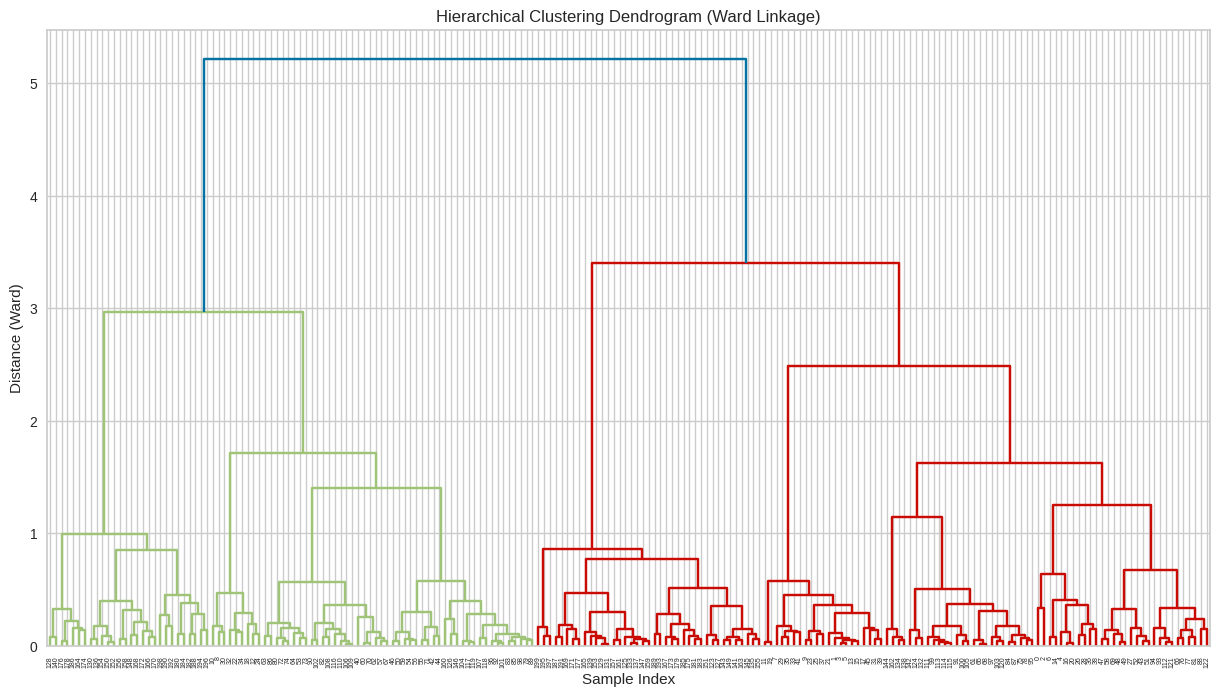

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled_hierarchical = scaler.fit_transform(df)


# Perform hierarchical clustering using the 'ward' linkage method
linked = linkage(df_scaled_hierarchical, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linked, orientation='top')
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance (Ward)')
plt.show()

Based on the dendrogram alone, the most optimal number of clusters is likely **5**. This is because cutting the dendrogram at a height that yields 5 clusters results in distinct and reasonably sized clusters.

In [ ]:
# Project the original data onto the first two principal components

pca_2d = PCA(n_components = 2)
data_pca_2d = pca_2d.fit_transform(df_reduced_s2)

# Reconstruct into a DataFrame

data_pca_2d_df = pd.DataFrame(data_pca_2d, columns = ['PC0', 'PC1'])
data_pca_2d_df

,PC0,PC1
0,-0.192221,-0.319683
1,-0.458175,0.018152
2,0.052562,-0.551854
3,-0.402357,0.014239
4,-0.031648,-0.155578
...,...,...
195,-0.264686,0.131248
196,0.231202,-0.118796
197,-0.272601,0.051514
198,0.117597,-0.369754


# **A. Visualize the x = PC0 and y = PC1, Show Data 50 with marker of star (*) using 2D scatter plot**

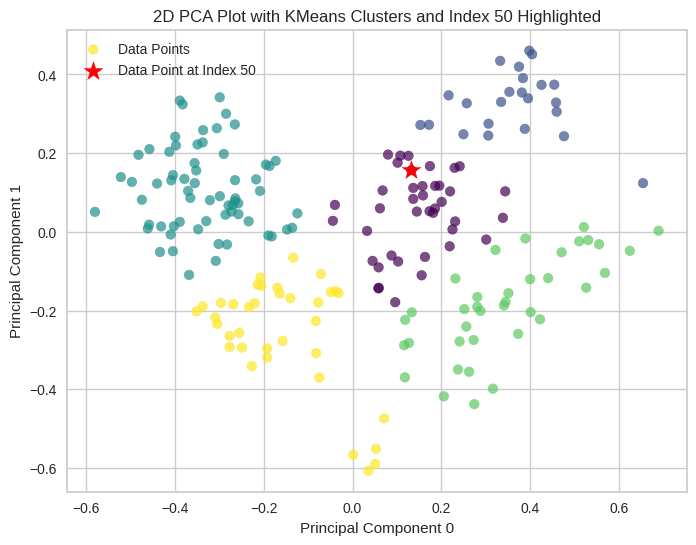

Data point at index 50 belongs to Cluster 0


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# Perform KMeans clustering with 5 clusters (based on dendrogram)
kmeans_2d = KMeans(n_clusters=5, random_state=random_s, n_init=10)
clusters_2d = kmeans_2d.fit_predict(data_pca_2d)

# Add cluster labels to a DataFrame for easier plotting
data_pca_2d_df = pd.DataFrame(data_pca_2d, columns=['PC0', 'PC1'])
data_pca_2d_df['Cluster'] = clusters_2d

# Visualize the clusters and highlight data point 50
plt.figure(figsize=(8, 6))

plt.scatter(data_pca_2d_df['PC0'], data_pca_2d_df['PC1'], c=data_pca_2d_df['Cluster'], cmap='viridis', alpha=0.7, label='Data Points')

# Highlight data point at index 50
plt.scatter(data_pca_2d_df.loc[50, 'PC0'], data_pca_2d_df.loc[50, 'PC1'], color='red', marker='*', s=200, label='Data Point at Index 50')

plt.title('2D PCA Plot with KMeans Clusters and Index 50 Highlighted')
plt.xlabel('Principal Component 0')
plt.ylabel('Principal Component 1')
plt.grid(True)
plt.legend()
plt.show()

# Print the cluster of data point at index 50
cluster_50 = clusters_2d[50]
print(f"Data point at index 50 belongs to Cluster {cluster_50}")

# **B. Visualize the x = PC0, y = PC1, and z = PC2, Show or Trace Data 50 with black circle, using scatter_3D.**

In [ ]:
# Project the original data onto the first two principal components

pca_3d = PCA(n_components = 3)
data_pca_3d = pca_3d.fit_transform(df_reduced_s2)

# Reconstruct into a DataFrame

data_pca_3d_df = pd.DataFrame(data_pca_3d, columns = ['PC0', 'PC1', 'PC2'])
data_pca_3d_df

,PC0,PC1,PC2
0,-0.192221,-0.319683,-0.398865
1,-0.458175,0.018152,-0.381857
2,0.052562,-0.551854,-0.401155
3,-0.402357,0.014239,-0.372833
4,-0.031648,-0.155578,-0.368647
...,...,...,...
195,-0.264686,0.131248,0.491871
196,0.231202,-0.118796,0.534280
197,-0.272601,0.051514,0.535804
198,0.117597,-0.369754,0.606085


In [ ]:
from sklearn.cluster import AgglomerativeClustering
import plotly.express as px
import pandas as pd
from sklearn.decomposition import PCA

# Create an Agglomerative Clustering model with 5 clusters
agg_clustering = AgglomerativeClustering(n_clusters=5, linkage='ward')

# Fit the model and predict the clusters on the 3D PCA data
# Use data_pca_3d_df which contains the 3D PCA coordinates
clusters_3d = agg_clustering.fit_predict(data_pca_3d_df[['PC0', 'PC1', 'PC2']])

# Add the new cluster labels to the DataFrame
data_pca_3d_df['Cluster'] = clusters_3d
data_pca_3d_df['Cluster'] = data_pca_3d_df['Cluster'].astype(str) # Convert to string for coloring

# Create a 3D scatter plot with Plotly, colored by cluster
fig = px.scatter_3d(
    data_pca_3d_df,
    x='PC0',
    y='PC1',
    z='PC2',
    color='Cluster', # Color by the Agglomerative Clusters
    opacity=0.8,
    title="3D Scatter Plot with Agglomerative Clusters and Index 50 Highlighted"
)

# Add the specific data point at index 50 as a separate trace with a black circle
index_to_highlight = 50

fig.add_scatter3d(
    x=[data_pca_3d_df.loc[index_to_highlight, 'PC0']],
    y=[data_pca_3d_df.loc[index_to_highlight, 'PC1']],
    z=[data_pca_3d_df.loc[index_to_highlight, 'PC2']],
    mode='markers',
    marker=dict(
        color='black',
        size=10,
        symbol='circle'
    ),
    name=f'Data Point at Index {index_to_highlight}'
)

fig.show()

# Print the cluster of data point at index 50
cluster_50_3d = data_pca_3d_df.loc[index_to_highlight, 'Cluster']
print(f"Data point at index {index_to_highlight} belongs to Cluster {cluster_50_3d} based on 3D Agglomerative Clustering.")

Data point at index 50 belongs to Cluster 0 based on 3D Agglomerative Clustering.
